 # MKA-MLF, Lab_07 Convolutional Neural Networks

## Exercise - Hand-written digits recognition

Create CNN which will process and recognize handwritten digits. For this purposes please use the MNIST database (Modified National Institute of Standards and Technology database) which is a large database of handwritten digits that is commonly used for training various image processing systems.

The datasample of the MNIST datasets can be see in the following picture

![mnist_data_sample.png](attachment:eb3e0d6a-ccb0-499d-9847-ecbc554dbce0.png)

### Task description

In the terms of machine learning, the Hand-written digits recognition can be threated as a multi-class classification problem. This is very important knowledge to structure our model in the correct way (Especially the output-layer, including the number of neurons and activations function and the overall loss function and classification metrics)

### 0. Import libraries

Import the all necessary libraries, you can get inspired by the previous exercises. You can improst the libraries gradually, when do you progressing with the task

In [1]:
from tensorflow import keras
from keras.models import Sequential
from keras.datasets import mnist
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
###################################
# Write your own code here #
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
import seaborn as sns


###################################
font = {'weight' : 'bold',
        'size'   : 12}

matplotlib.rc('font', **font)

### 1. Dataset

#### 1.1 Load Dataset

You can load the dataset using the following code

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


#### 1.2 Dataset examination

Using the following code, display random images,

In [3]:
def display_random_images(x_data: np.array, y_data: np.array, count: int = 10) -> None:
  index = np.array(len(x_data))
  selected_ind = np.random.choice(index, count)

  selected_img = x_data[selected_ind]
  selected_labels = y_data[selected_ind]
  concat_img = np.concatenate(selected_img, axis=1)

  plt.figure(figsize=(20,10))
  plt.imshow(concat_img, cmap="gray")

  for id_label, label in enumerate(selected_labels):
    plt.text(14 + 28*id_label, 28*(5/4), label)
  plt.axis('off')
  plt.show()

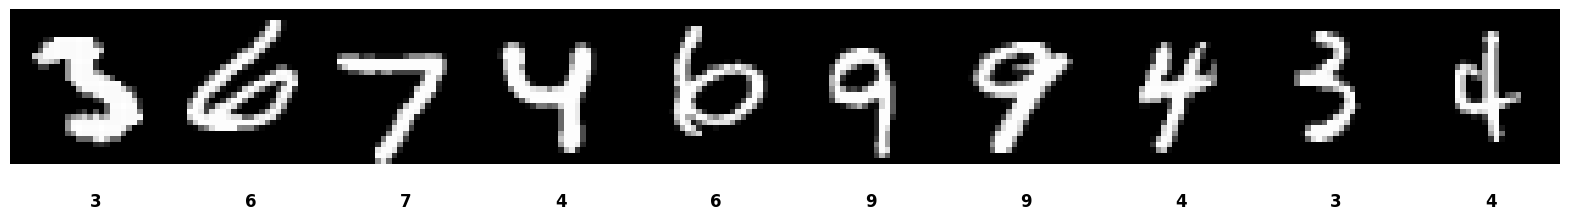

In [ ]:
display_random_images(X_train, y_train)

Examine the dataset. Answer for yourself the following questions:

- What kind of data occurs in our dataset?
- How many data samples do we have in train and test datasets?
- How many colour channels does the input variable have?
- What is the size of the input images?
- What is the necessary preprocessing of the input data X?
- How many classes do we have in target varoable?
- What is the necessary preprocessing of target variable y?

#### 1.3 Dataset preprocessing

Perform the necessary data preprocessing. The best way to preprocess the data would be one hot encoding for the target variable and normalization for the input variable (using min-max or z-score normalization)

In [4]:
###################################
# Write your own code here #
# 1. Reshape X to include the color channel (28x28x1 images)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

# 2. Min-Max Normalization (convert pixel values from 0-255 to 0-1)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 3. One-hot encoding for the target variable (transform digits 0-9 into categories)
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)


###################################

### 2. Build the model

In this section, your task will be to define the model architecture. The intial structure can be defined as follows:

Input_layer -> Convolutional_layer(kernel_size=(3,3), no_channels=32) -> Maxpooling_layer(kernel_size=(2, 2)) -> Flatten_layer -> Dense_layer (num_classes)
    
    


#### 2.1 Define the model structure

In [5]:
model = Sequential()
###################################
# Write your own code here #

# Convolutional layer with 32 channels, 3x3 kernel, and ReLU activation
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

# Max pooling layer with 2x2 kernel to reduce spatial dimensions
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten layer to convert 2D feature maps into a 1D vector
model.add(Flatten())

# Dense output layer with 10 neurons (for classes 0-9) and softmax activation
model.add(Dense(10, activation='softmax'))

###################################


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### 2.2 Compile the model

Build the model, use the relevant metrics, optimizer and loss function. While choosing the metrics and loss function, consider fact that we are are trying to solve the multiclass classification problem

In [6]:
# Use categorical crossentropy since we applied one-hot encoding to our 10 classes
loss = 'categorical_crossentropy'

# Set a standard learning rate for the Adam optimizer
learning_rate = 0.001

# Import Adam optimizer to apply the specific learning rate
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=learning_rate)

# We want to track accuracy during training
metrics = ['accuracy']

###################################
# Write your own code here #

# Compile the model with the defined parameters
model.compile(loss=loss, optimizer=optimizer, metrics=metrics)

###################################
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,410 (212.54 KB)

 Trainable params: 54,410 (212.54 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Training stage

#### 3.1 Model training

train your model, define the relevant hyperparameters (no. epochs, batch_size), use 20p of the training data for validation

In [7]:
###################################
# Write your own code here #
# Define the relevant hyperparameters
epochs = 10
batch_size = 64

# Train the model and save the results in 'history' for later plotting
# validation_split=0.2 automatically uses 20% of the training data for validation
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2
)


###################################

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9121 - loss: 0.3155 - val_accuracy: 0.9613 - val_loss: 0.1495
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9661 - loss: 0.1191 - val_accuracy: 0.9732 - val_loss: 0.0951
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.9764 - loss: 0.0834 - val_accuracy: 0.9748 - val_loss: 0.0872
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9804 - loss: 0.0680 - val_accuracy: 0.9785 - val_loss: 0.0747
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9835 - loss: 0.0577 - val_accuracy: 0.9782 - val_loss: 0.0713
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.9849 - loss: 0.0507 - val_accuracy: 0.9813 - val_loss: 0.0657
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9867 - loss: 0.0449 - val_accuracy: 0.9797 - val_loss: 0.0694
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9878 - loss: 0.0401 - 

#### 3.1 Model Evaluation on validation data

Plot the development of the training and validation loss, and training and validation metrics.

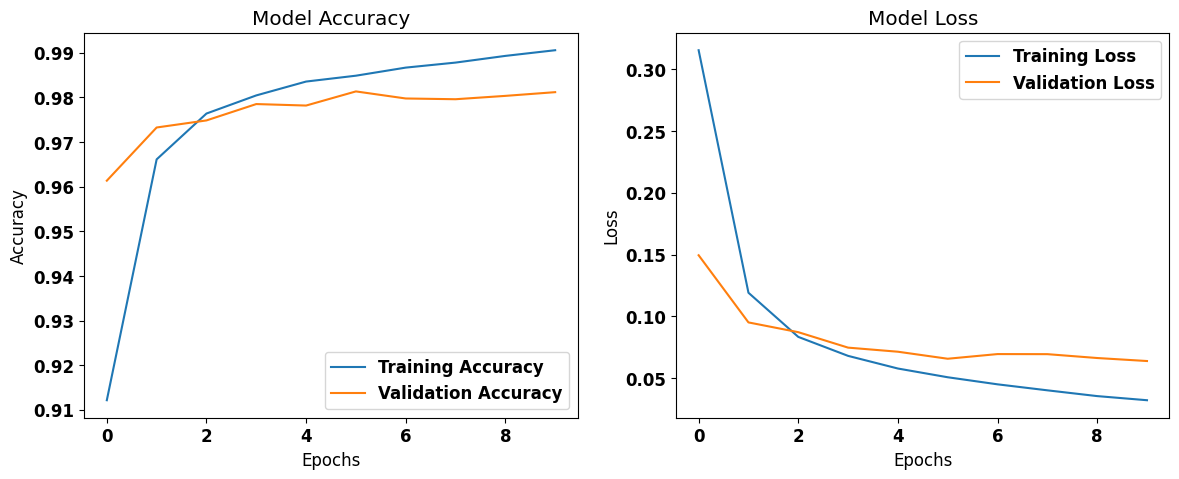

In [11]:
###################################
# Write your own code here #
# Set up the figure size for better readability
plt.figure(figsize=(14, 5))

# 1. Plot Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 2. Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Display the plots
plt.show()


###################################

### 4. Model evaluation

Evaluate the model on the testing dataset using the relevant metrics. Use the confusion metrics as the one of the metrics.

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9815 - loss: 0.0562
Test Accuracy: 0.9815
Test Loss: 0.0562
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


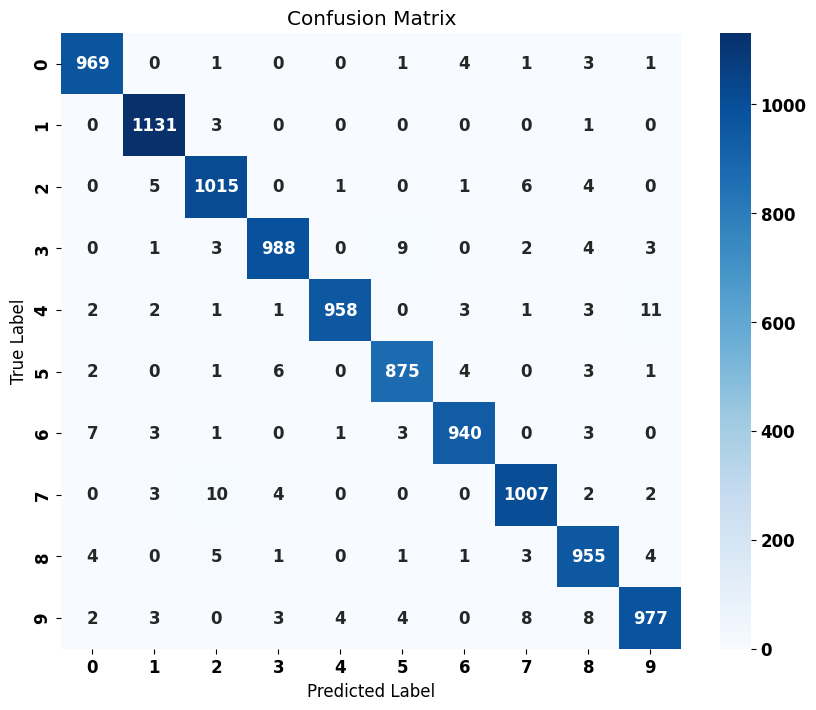

In [9]:
###################################
# Write your own code here #

# Evaluate the model on the test dataset to get overall loss and accuracy
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Generate predictions for the test dataset
y_pred = model.predict(X_test)

# Convert predictions and true labels from one-hot encoding back to class integers (0-9)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Calculate the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

###################################

### 5. Hyperparameter tunning and regularization techniques

When your code is ready and fully functional, try several changes in the hyperparameters and see how they influence the testing metrics. Try changes in the network structure. You can also try adding regularization techniques such as L1, L2, and Dropout. Based on the development of training and validation loss, try to identify overfitting and avoid it

### Model Tuning and Regularization Adjustments

In this section, we significantly improved the initial model's architecture and training process to prevent overfitting and boost its ability to generalize on unseen data. First, we deepened the network by adding a **second convolutional block** (`Conv2D` + `MaxPooling2D`), which allows the model to extract and learn more complex spatial features from the images. To actively combat overfitting, we introduced **Dropout layers**, which randomly deactivate a percentage of neurons during training, forcing the network to learn more robust patterns instead of memorizing the training set. Additionally, we applied **L2 regularization** to the dense layer to penalize excessively large weights. Finally, regarding hyperparameter tuning, we increased the **batch size to 128** for more stable gradient updates and extended the training to **15 epochs** to give the deeper model sufficient time to converge properly.

In [10]:
from tensorflow.keras.regularizers import l2

# Define a new model to apply tuning and regularization
model_tuned = Sequential()

# 1. Structural change: First Convolutional Block
model_tuned.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model_tuned.add(MaxPooling2D(pool_size=(2, 2)))
# Regularization: Add Dropout to prevent overfitting by randomly turning off 25% of neurons
model_tuned.add(Dropout(0.25))

# Structural change: Second Convolutional Block to make the network deeper
model_tuned.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model_tuned.add(MaxPooling2D(pool_size=(2, 2)))
model_tuned.add(Dropout(0.25))

# Flatten the maps
model_tuned.add(Flatten())

# Regularization: Add L2 regularization to the Dense layer to penalize large weights
model_tuned.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
# Higher Dropout rate for the fully connected layer
model_tuned.add(Dropout(0.5))

# Output layer
model_tuned.add(Dense(10, activation='softmax'))

# Compile the model
model_tuned.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Hyperparameter tuning: Change batch_size to 128 and epochs to 15
history_tuned = model_tuned.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Evaluate the tuned model on the testing dataset
test_loss_tuned, test_acc_tuned = model_tuned.evaluate(X_test, y_test)
print(f"Tuned Model Test Accuracy: {test_acc_tuned:.4f}")
print(f"Tuned Model Test Loss: {test_loss_tuned:.4f}")

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.8670 - loss: 0.5775 - val_accuracy: 0.9743 - val_loss: 0.2198
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 28s 75ms/step - accuracy: 0.9572 - loss: 0.2524 - val_accuracy: 0.9827 - val_loss: 0.1558
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.9656 - loss: 0.1974 - val_accuracy: 0.9840 - val_loss: 0.1301
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 66ms/step - accuracy: 0.9689 - loss: 0.1736 - val_accuracy: 0.9860 - val_loss: 0.1174
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.9728 - loss: 0.1582 - val_accuracy: 0.9858 - val_loss: 0.1130
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.9739 - loss: 0.1525 - val_accuracy: 0.9877 - val_loss: 0.1067
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - accuracy: 0.9758 - loss: 0.1438 - val_accuracy: 0.9876 - val_loss: 0.1061
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 25s 67ms/step - accuracy: 0.9769 - loss: 0.1395 - val_accurac